# Klasifikasi Penyakit Tanaman Padi
## Sehat, Bacterial Leaf Blight (BLB), dan Blast
### Menggunakan ML Konvensional & Deep Learning Berbasis Transfer Learning

---

### Daftar Model:
1. **SVM** - Fitur piksel flatten (TANPA augmentasi)
2. **SVM + HOG** - Fitur HOG (TANPA augmentasi)
3. **MobileNetV2** - Transfer learning ImageNet (DENGAN augmentasi 4×)
4. **ResNet-50** - Transfer learning ImageNet (DENGAN augmentasi 4×)
5. **CNN + SVM (Stacking)** - CNN custom + SVM (DENGAN augmentasi 4×)


## 📦 0. Instalasi & Import Library

In [ ]:
!pip install scikit-image opencv-python-headless seaborn scikit-learn tensorflow

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import cv2
from PIL import Image
from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization,
    Conv2D, MaxPooling2D, Flatten, Input, ReLU, Activation
)
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K

warnings.filterwarnings('ignore')

# --- Seed untuk reproduktibilitas ---
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU tersedia       : {tf.config.list_physical_devices('GPU')}")

# Batasi penggunaan VRAM agar tidak OOM (opsional tapi disarankan)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth GPU diaktifkan")
    except RuntimeError as e:
        print(e)

# Mixed precision untuk efisiensi VRAM (float16)
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision policy:", mixed_precision.global_policy().name)

TensorFlow version : 2.20.0
GPU tersedia       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth GPU diaktifkan
Mixed precision policy: mixed_float16


## 1. Konfigurasi Global

In [ ]:
# ============================================================
#  KONFIGURASI — SESUAIKAN SEBELUM MENJALANKAN
# ============================================================

DATASET_DIR   = "/content/drive/MyDrive/dataset_penyakit_daun_padi"          # ← Ubah ke path dataset Anda
IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 16                   # Kecil agar hemat RAM
EPOCHS        = 100
LR            = 1e-4
AUG_FACTOR    = 4                    # Augmentasi 4× lipat
CLASSES       = ['Sehat', 'Blight', 'Blast']
N_CLASSES     = len(CLASSES)

# Path output
OUTPUT_DIR    = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Konfigurasi selesai.")
print(f"  Dataset dir  : {DATASET_DIR}")
print(f"  Image size   : {IMAGE_SIZE}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Epochs maks  : {EPOCHS}")
print(f"  Learning rate: {LR}")
print(f"  Aug factor   : {AUG_FACTOR}×")
print(f"  Kelas        : {CLASSES}")

Konfigurasi selesai.
  Dataset dir  : /content/drive/MyDrive/dataset_penyakit_daun_padi
  Image size   : (224, 224)
  Batch size   : 16
  Epochs maks  : 100
  Learning rate: 0.0001
  Aug factor   : 4×
  Kelas        : ['Sehat', 'Blight', 'Blast']


## 2. Loading & Pembagian Dataset

In [ ]:
def load_dataset(dataset_dir, image_size, classes):
    """
    Memuat semua gambar dari direktori dataset.
    Mendukung struktur flat maupun subfolder (field/white background).
    Menerapkan noise reduction + histogram equalization.
    Mengembalikan array numpy uint8 [0,255] (belum dinormalisasi).
    """
    images, labels = [], []
    label_map = {cls: idx for idx, cls in enumerate(classes)}

    for cls in classes:
        cls_dir = os.path.join(dataset_dir, cls)
        if not os.path.isdir(cls_dir):
            print(f"[PERINGATAN] Folder tidak ditemukan: {cls_dir}")
            continue

        # Kumpulkan semua file gambar (termasuk subfolder)
        filepaths = []
        for root, _, files in os.walk(cls_dir):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                    filepaths.append(os.path.join(root, f))

        for fp in filepaths:
            img = cv2.imread(fp)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, image_size, interpolation=cv2.INTER_LINEAR)

            # --- Noise reduction (median filter) ---
            img = cv2.medianBlur(img, 3)

            # --- Histogram equalization (per channel YCrCb) ---
            img_ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
            img_ycrcb[:, :, 0] = cv2.equalizeHist(img_ycrcb[:, :, 0])
            img = cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2RGB)

            images.append(img)
            labels.append(label_map[cls])

        print(f"  [{cls}] {len(filepaths)} gambar dimuat")

    images = np.array(images, dtype=np.uint8)
    labels = np.array(labels, dtype=np.int32)
    print(f"\nTotal dataset: {len(images)} gambar, shape: {images.shape}")
    return images, labels


print("Memuat dataset...")
X_all, y_all = load_dataset(DATASET_DIR, IMAGE_SIZE, CLASSES)

# ---- Stratified split 80:10:10 ----
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.10, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=SEED, stratify=y_temp  # 0.1/0.9 ≈ 0.1111
)

print(f"\nPembagian dataset:")
print(f"  Training   : {len(X_train)} gambar")
print(f"  Validation : {len(X_val)}  gambar")
print(f"  Testing    : {len(X_test)}  gambar")

# Distribusi kelas
for split_name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = [np.sum(y == i) for i in range(N_CLASSES)]
    print(f"  {split_name}: {dict(zip(CLASSES, dist))}")

Memuat dataset...
  [Sehat] 270 gambar dimuat
  [Blight] 270 gambar dimuat
  [Blast] 270 gambar dimuat

Total dataset: 810 gambar, shape: (810, 224, 224, 3)

Pembagian dataset:
  Training   : 648 gambar
  Validation : 81  gambar
  Testing    : 81  gambar
  Train: {'Sehat': np.int64(216), 'Blight': np.int64(216), 'Blast': np.int64(216)}
  Val: {'Sehat': np.int64(27), 'Blight': np.int64(27), 'Blast': np.int64(27)}
  Test: {'Sehat': np.int64(27), 'Blight': np.int64(27), 'Blast': np.int64(27)}


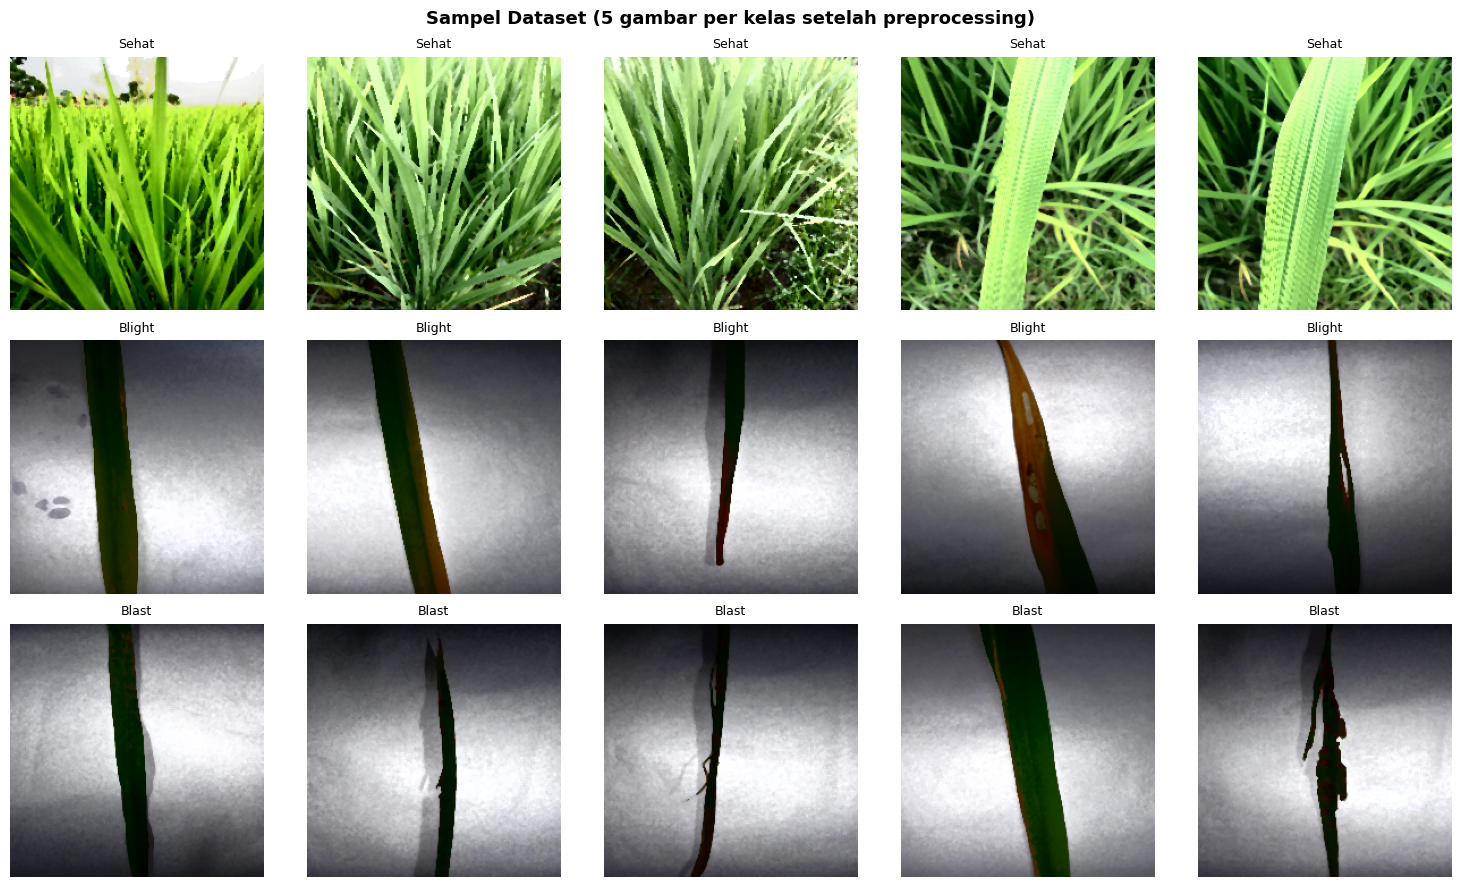

In [ ]:
# ---- Visualisasi sampel dataset ----
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row, cls_idx in enumerate(range(N_CLASSES)):
    idxs = np.where(y_all == cls_idx)[0][:5]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(X_all[idx])
        axes[row, col].set_title(f"{CLASSES[cls_idx]}", fontsize=9)
        axes[row, col].axis('off')
plt.suptitle("Sampel Dataset (5 gambar per kelas setelah preprocessing)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "00_sample_dataset.png"), dpi=100, bbox_inches='tight')
plt.show()

## 3. Helper Functions: Preprocessing & Augmentasi

In [ ]:
# =====================================================
#  NORMALISASI
# =====================================================

def normalize_standard(images):
    """Normalisasi ke [0,1] — untuk SVM dan CNN custom."""
    return images.astype(np.float32) / 255.0

def normalize_imagenet(images):
    """Normalisasi ImageNet mean/std — untuk MobileNetV2 & ResNet50."""
    imgs = images.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return (imgs - mean) / std


# =====================================================
#  AUGMENTASI (hanya untuk training DL)
# =====================================================

def augment_image(img_uint8):
    """
    Augmentasi satu gambar (uint8 [0,255]):
    - Rotasi acak 10–45 derajat
    - Flip horizontal/vertikal (prob 50%)
    - Zoom acak 10–20%
    - Brightness acak 0.8–1.2×
    """
    img = img_uint8.copy().astype(np.float32)
    h, w = img.shape[:2]

    # Rotasi
    angle = np.random.uniform(10, 45) * np.random.choice([-1, 1])
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Flip
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)  # horizontal
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 0)  # vertikal

    # Zoom
    zoom = np.random.uniform(0.80, 0.90)  # 10–20% zoom in
    crop_h, crop_w = int(h * zoom), int(w * zoom)
    y0 = (h - crop_h) // 2
    x0 = (w - crop_w) // 2
    img = img[y0:y0 + crop_h, x0:x0 + crop_w]
    img = cv2.resize(img, (w, h), interpolation=cv2.INTER_LINEAR)

    # Brightness
    factor = np.random.uniform(0.8, 1.2)
    img = np.clip(img * factor, 0, 255)

    return img.astype(np.uint8)


def augment_dataset(X, y, factor=4):
    """
    Membuat dataset augmented sebesar factor× dari X.
    Mengembalikan gabungan data asli + augmented.
    Hemat memori: proses per-batch.
    """
    aug_images, aug_labels = [X.copy()], [y.copy()]
    for rep in range(factor - 1):
        batch_imgs = np.array([augment_image(img) for img in X], dtype=np.uint8)
        aug_images.append(batch_imgs)
        aug_labels.append(y.copy())
        print(f"  Augmentasi ke-{rep + 2}/{factor} selesai ({len(X)} gambar)")
        gc.collect()
    X_aug = np.concatenate(aug_images, axis=0)
    y_aug = np.concatenate(aug_labels, axis=0)
    # Shuffle
    idx = np.random.permutation(len(X_aug))
    return X_aug[idx], y_aug[idx]


# =====================================================
#  HELPER: CALLBACK STANDAR
# =====================================================

def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5,
            min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            filepath=os.path.join(OUTPUT_DIR, f"best_{model_name}.h5"),
            monitor='val_accuracy', save_best_only=True,
            mode='max', verbose=0
        )
    ]


# =====================================================
#  HELPER: EVALUASI & VISUALISASI
# =====================================================

def evaluate_model_dl(model, X, y_true, classes, preprocess_fn=None):
    """Evaluasi model Keras, return dict metrik."""
    X_proc = preprocess_fn(X) if preprocess_fn else normalize_standard(X)
    y_pred_prob = model.predict(X_proc, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    return compute_metrics(y_true, y_pred, classes)


def evaluate_model_sk(model, X, y_true, classes):
    """Evaluasi model sklearn, return dict metrik."""
    y_pred = model.predict(X)
    return compute_metrics(y_true, y_pred, classes)


def compute_metrics(y_true, y_pred, classes):
    metrics = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1'       : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'cm'       : confusion_matrix(y_true, y_pred),
        'report'   : classification_report(y_true, y_pred, target_names=classes)
    }
    return metrics


def plot_confusion_matrix(cm, classes, title, ax, cmap='Blues'):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Prediksi', fontsize=10)
    ax.set_ylabel('Aktual', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')


def plot_training_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{model_name} – Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{model_name} – Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"history_{model_name}.png"), dpi=100)
    plt.show()


# Storage hasil semua model
ALL_RESULTS = {}
print("Helper functions siap.")

Helper functions siap.


## Model 1: SVM (Fitur Piksel Flatten)
> **Tanpa augmentasi data.** Menggunakan StandardScaler + PCA untuk efisiensi memori.

In [ ]:
print("=" * 60)
print("MODEL 1: SVM – Fitur Piksel Flatten (TANPA Augmentasi)")
print("=" * 60)

# 1. Normalisasi & Flatten
X_train_svm = normalize_standard(X_train).reshape(len(X_train), -1)  # (N, 150528)
X_val_svm   = normalize_standard(X_val).reshape(len(X_val), -1)
X_test_svm  = normalize_standard(X_test).reshape(len(X_test), -1)

print(f"Dimensi fitur awal: {X_train_svm.shape[1]:,} dimensi")

# 2. StandardScaler
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train_svm)
X_val_svm   = scaler_svm.transform(X_val_svm)
X_test_svm  = scaler_svm.transform(X_test_svm)

# 3. PCA untuk reduksi dimensi (hemat RAM dari 150K → 200 dim)
#    Dengan n_components=200, biasanya 85–95% variansi terjaga
print("\nAplikasi PCA (n_components=200) untuk reduksi memori...")
pca_svm = PCA(n_components=200, random_state=SEED, svd_solver='randomized')
X_train_svm = pca_svm.fit_transform(X_train_svm)
X_val_svm   = pca_svm.transform(X_val_svm)
X_test_svm  = pca_svm.transform(X_test_svm)

var_explained = np.sum(pca_svm.explained_variance_ratio_) * 100
print(f"Variansi terjaga : {var_explained:.2f}%")
print(f"Dimensi setelah PCA: {X_train_svm.shape[1]}")

# 4. Grid Search SVM
print("\nGrid Search SVM (5-fold CV)...")
param_grid_svm = {
    'C'    : [1, 10, 100],
    'gamma': ['scale', 'auto']
}
svm_model = GridSearchCV(
    SVC(kernel='rbf', decision_function_shape='ovr', random_state=SEED),
    param_grid_svm, cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)
svm_model.fit(X_train_svm, y_train)
print(f"Best params: {svm_model.best_params_}  |  CV score: {svm_model.best_score_:.4f}")

# 5. Evaluasi
svm_result = evaluate_model_sk(svm_model, X_test_svm, y_test, CLASSES)
ALL_RESULTS['SVM'] = svm_result

print(f"\n📊 Hasil SVM pada Test Set:")
print(f"  Accuracy : {svm_result['accuracy']:.4f}")
print(f"  Precision: {svm_result['precision']:.4f}")
print(f"  Recall   : {svm_result['recall']:.4f}")
print(f"  F1-Score : {svm_result['f1']:.4f}")
print(f"\n{svm_result['report']}")

gc.collect()

MODEL 1: SVM – Fitur Piksel Flatten (TANPA Augmentasi)
Dimensi fitur awal: 150,528 dimensi

Aplikasi PCA (n_components=200) untuk reduksi memori...
Variansi terjaga : 91.38%
Dimensi setelah PCA: 200

Grid Search SVM (5-fold CV)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'C': 100, 'gamma': 'scale'}  |  CV score: 0.7501

📊 Hasil SVM pada Test Set:
  Accuracy : 0.7407
  Precision: 0.7539
  Recall   : 0.7407
  F1-Score : 0.7437

              precision    recall  f1-score   support

       Sehat       0.91      0.78      0.84        27
      Blight       0.69      0.67      0.68        27
       Blast       0.66      0.78      0.71        27

    accuracy                           0.74        81
   macro avg       0.75      0.74      0.74        81
weighted avg       0.75      0.74      0.74        81



54

## Model 2: SVM + HOG
> **Tanpa augmentasi data.** HOG mengekstraksi fitur tepi & orientasi gradien.

In [ ]:
print("=" * 60)
print("MODEL 2: SVM + HOG (TANPA Augmentasi)")
print("=" * 60)

def extract_hog_features(images):
    """
    Ekstraksi fitur HOG dari batch gambar.
    Parameter: 9 orientasi, sel 8×8, blok 2×2, normalisasi L2-Hys.
    Input : uint8 array (N, 224, 224, 3)
    Output: float32 array (N, n_features_hog)
    """
    feats = []
    for img in images:
        # Konversi ke grayscale untuk HOG
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True
        )
        feats.append(feat)
    return np.array(feats, dtype=np.float32)


print("Mengekstraksi fitur HOG...")
X_train_hog = extract_hog_features(X_train)
X_val_hog   = extract_hog_features(X_val)
X_test_hog  = extract_hog_features(X_test)
print(f"Dimensi fitur HOG: {X_train_hog.shape[1]:,}")

# StandardScaler
scaler_hog = StandardScaler()
X_train_hog = scaler_hog.fit_transform(X_train_hog)
X_val_hog   = scaler_hog.transform(X_val_hog)
X_test_hog  = scaler_hog.transform(X_test_hog)

# Grid Search SVM
print("\nGrid Search SVM+HOG (5-fold CV)...")
param_grid_hog = {
    'C'    : [1, 10, 100],
    'gamma': ['scale', 'auto']
}
svm_hog_model = GridSearchCV(
    SVC(kernel='rbf', decision_function_shape='ovr', random_state=SEED),
    param_grid_hog, cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)
svm_hog_model.fit(X_train_hog, y_train)
print(f"Best params: {svm_hog_model.best_params_}  |  CV score: {svm_hog_model.best_score_:.4f}")

# Evaluasi
hog_result = evaluate_model_sk(svm_hog_model, X_test_hog, y_test, CLASSES)
ALL_RESULTS['SVM+HOG'] = hog_result

print(f"\n📊 Hasil SVM+HOG pada Test Set:")
print(f"  Accuracy : {hog_result['accuracy']:.4f}")
print(f"  Precision: {hog_result['precision']:.4f}")
print(f"  Recall   : {hog_result['recall']:.4f}")
print(f"  F1-Score : {hog_result['f1']:.4f}")
print(f"\n{hog_result['report']}")

del X_train_hog, X_val_hog, X_test_hog
gc.collect()

MODEL 2: SVM + HOG (TANPA Augmentasi)
Mengekstraksi fitur HOG...
Dimensi fitur HOG: 6,084

Grid Search SVM+HOG (5-fold CV)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'C': 10, 'gamma': 'scale'}  |  CV score: 0.7330

📊 Hasil SVM+HOG pada Test Set:
  Accuracy : 0.7407
  Precision: 0.7553
  Recall   : 0.7407
  F1-Score : 0.7406

              precision    recall  f1-score   support

       Sehat       0.87      0.74      0.80        27
      Blight       0.74      0.63      0.68        27
       Blast       0.66      0.85      0.74        27

    accuracy                           0.74        81
   macro avg       0.76      0.74      0.74        81
weighted avg       0.76      0.74      0.74        81



27

## Model 3: MobileNetV2 (Transfer Learning)
> **Dengan augmentasi 4×.** Semua layer konvolusi dibekukan (frozen).

MODEL 3: MobileNetV2 – Transfer Learning (DENGAN Augmentasi 4×)

Membuat data augmented untuk training MobileNetV2...
  Augmentasi ke-2/4 selesai (648 gambar)
  Augmentasi ke-3/4 selesai (648 gambar)
  Augmentasi ke-4/4 selesai (648 gambar)
Training set setelah augmentasi: 2592 gambar
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

...

162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6937 - loss: 0.7146 - val_accuracy: 0.7901 - val_loss: 0.5781 - learning_rate: 1.0000e-04
Epoch 8/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7083 - loss: 0.6942 - val_accuracy: 0.7901 - val_loss: 0.5697 - learning_rate: 1.0000e-04
Epoch 9/100
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7030 - loss: 0.6886

162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.7076 - loss: 0.6855 - val_accuracy: 0.8025 - val_loss: 0.5581 - learning_rate: 1.0000e-04
Epoch 10/100
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7290 - loss: 0.6467

162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7280 - loss: 0.6575 - val_accuracy: 0.8148 - val_loss: 0.5398 - learning_rate: 1.0000e-04
Epoch 11/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7346 - loss: 0.6342 - val_accuracy: 0.8025 - val_loss: 0.5362 - learning_rate: 1.0000e-04
Epoch 12/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7346 - loss: 0.6309 - val_accuracy: 0.8148 - val_loss: 0.5236 - learning_rate: 1.0000e-04
Epoch 13/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7330 - loss: 0.6222 - val_accuracy: 0.8148 - val_loss: 0.5128 - learning_rate: 1.0000e-04
Epoch 14/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.7481 - loss: 0.6022 - val_accuracy: 0.8148 - val_loss: 0.5061 - learning_rate: 1.0000e-04
Epoch 15/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7639 - loss: 0.5695 - val_accuracy: 0.8148 - val_loss: 0.4984 - learning_rate: 1.0000e-04
Epoch 16/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - a

162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.7855 - loss: 0.5282 - val_accuracy: 0.8272 - val_loss: 0.4837 - learning_rate: 1.0000e-04
Epoch 21/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7882 - loss: 0.5151 - val_accuracy: 0.8272 - val_loss: 0.4764 - learning_rate: 1.0000e-04
Epoch 22/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.7863 - loss: 0.5099 - val_accuracy: 0.8272 - val_loss: 0.4668 - learning_rate: 1.0000e-04
Epoch 23/100
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7807 - loss: 0.4955

162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7890 - loss: 0.4964 - val_accuracy: 0.8395 - val_loss: 0.4697 - learning_rate: 1.0000e-04
Epoch 24/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.7982 - loss: 0.4958 - val_accuracy: 0.8395 - val_loss: 0.4670 - learning_rate: 1.0000e-04
Epoch 25/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7951 - loss: 0.4903 - val_accuracy: 0.8395 - val_loss: 0.4635 - learning_rate: 1.0000e-04
Epoch 26/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8017 - loss: 0.4795 - val_accuracy: 0.8395 - val_loss: 0.4585 - learning_rate: 1.0000e-04
Epoch 27/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8005 - loss: 0.4734 - val_accuracy: 0.8272 - val_loss: 0.4560 - learning_rate: 1.0000e-04
Epoch 28/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8125 - loss: 0.4646 - val_accuracy: 0.8272 - val_loss: 0.4506 - learning_rate: 1.0000e-04
Epoch 29/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - ac

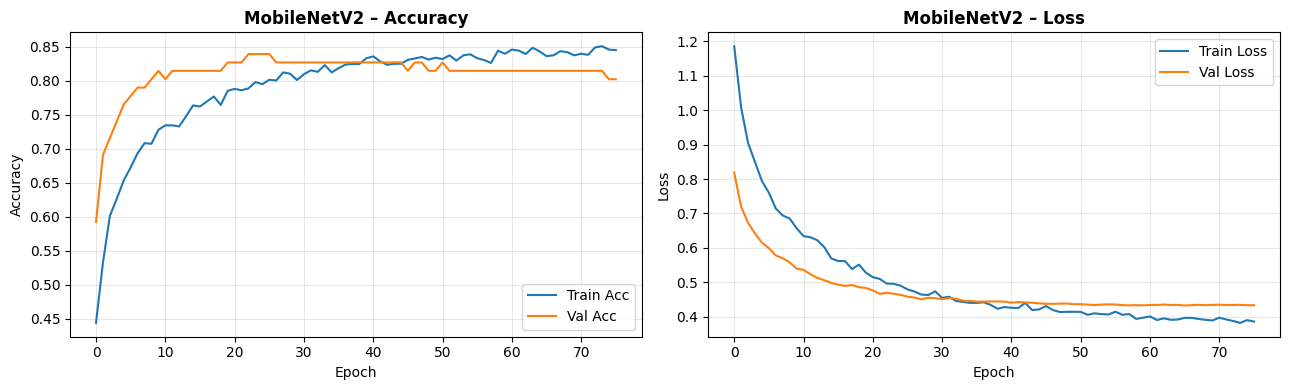


📊 Hasil MobileNetV2 pada Test Set:
  Accuracy : 0.8272
  Precision: 0.8270
  Recall   : 0.8272
  F1-Score : 0.8257

              precision    recall  f1-score   support

       Sehat       0.86      0.93      0.89        27
      Blight       0.83      0.74      0.78        27
       Blast       0.79      0.81      0.80        27

    accuracy                           0.83        81
   macro avg       0.83      0.83      0.83        81
weighted avg       0.83      0.83      0.83        81



In [ ]:
print("=" * 60)
print("MODEL 3: MobileNetV2 – Transfer Learning (DENGAN Augmentasi 4×)")
print("=" * 60)

# 1. Augmentasi training set
print("\nMembuat data augmented untuk training MobileNetV2...")
X_train_aug, y_train_aug = augment_dataset(X_train, y_train, factor=AUG_FACTOR)
print(f"Training set setelah augmentasi: {len(X_train_aug)} gambar")

# 2. Preprocessing ImageNet
X_train_mn = normalize_imagenet(X_train_aug).astype(np.float32)
X_val_mn   = normalize_imagenet(X_val).astype(np.float32)
X_test_mn  = normalize_imagenet(X_test).astype(np.float32)

y_train_mn = to_categorical(y_train_aug, N_CLASSES)
y_val_mn   = to_categorical(y_val, N_CLASSES)

# 3. Bangun model
K.clear_session()

base_mn = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)
base_mn.trainable = False  # Freeze semua layer konvolusi

inputs_mn = Input(shape=(*IMAGE_SIZE, 3))
x = base_mn(inputs_mn, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs_mn = Dense(N_CLASSES, activation='softmax', dtype='float32')(x)

model_mn = Model(inputs_mn, outputs_mn)
model_mn.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_mn.summary()

# 4. Training
print("\nMelatih MobileNetV2...")
history_mn = model_mn.fit(
    X_train_mn, y_train_mn,
    validation_data=(X_val_mn, y_val_mn),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('MobileNetV2'),
    verbose=1
)

# 5. Evaluasi
plot_training_history(history_mn, 'MobileNetV2')

y_pred_mn = np.argmax(model_mn.predict(X_test_mn, batch_size=BATCH_SIZE, verbose=0), axis=1)
mn_result = compute_metrics(y_test, y_pred_mn, CLASSES)
ALL_RESULTS['MobileNetV2'] = mn_result

print(f"\n📊 Hasil MobileNetV2 pada Test Set:")
print(f"  Accuracy : {mn_result['accuracy']:.4f}")
print(f"  Precision: {mn_result['precision']:.4f}")
print(f"  Recall   : {mn_result['recall']:.4f}")
print(f"  F1-Score : {mn_result['f1']:.4f}")
print(f"\n{mn_result['report']}")

del X_train_aug, y_train_aug, X_train_mn, X_val_mn, X_test_mn, y_train_mn, y_val_mn
gc.collect()
K.clear_session()

## Model 4: ResNet-50 (Transfer Learning)
> **Dengan augmentasi 4×.** Skip connections memungkinkan arsitektur sangat dalam.

MODEL 4: ResNet-50 – Transfer Learning (DENGAN Augmentasi 4×)

Membuat data augmented untuk training ResNet-50...
  Augmentasi ke-2/4 selesai (648 gambar)
  Augmentasi ke-3/4 selesai (648 gambar)
  Augmentasi ke-4/4 selesai (648 gambar)
Training set setelah augmentasi: 2592 gambar
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

...

162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.6686 - loss: 0.7403 - val_accuracy: 0.7160 - val_loss: 0.6554 - learning_rate: 1.0000e-04
Epoch 25/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.6782 - loss: 0.7346 - val_accuracy: 0.7160 - val_loss: 0.6517 - learning_rate: 1.0000e-04
Epoch 26/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.6879 - loss: 0.7265 - val_accuracy: 0.7160 - val_loss: 0.6466 - learning_rate: 1.0000e-04
Epoch 27/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.6921 - loss: 0.7112 - val_accuracy: 0.7037 - val_loss: 0.6437 - learning_rate: 1.0000e-04
Epoch 28/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.6898 - loss: 0.7202 - val_accuracy: 0.7160 - val_loss: 0.6419 - learning_rate: 1.0000e-04
Epoch 29/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.6964 - loss: 0.7059 - val_accuracy: 0.7160 - val_loss: 0.6407 - learning_rate: 1.0000e-04
Epoch 30/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/ste

162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.6806 - loss: 0.7082 - val_accuracy: 0.7284 - val_loss: 0.6395 - learning_rate: 1.0000e-04
Epoch 31/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.6929 - loss: 0.7138 - val_accuracy: 0.7284 - val_loss: 0.6388 - learning_rate: 1.0000e-04
Epoch 32/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.6925 - loss: 0.7004 - val_accuracy: 0.7284 - val_loss: 0.6391 - learning_rate: 1.0000e-04
Epoch 33/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.6998 - loss: 0.6941 - val_accuracy: 0.7284 - val_loss: 0.6379 - learning_rate: 1.0000e-04
Epoch 34/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.6960 - loss: 0.6961 - val_accuracy: 0.7284 - val_loss: 0.6365 - learning_rate: 1.0000e-04
Epoch 35/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.6998 - loss: 0.7027 - val_accuracy: 0.7284 - val_loss: 0.6351 - learning_rate: 1.0000e-04
Epoch 36/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/ste

162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.7010 - loss: 0.6997 - val_accuracy: 0.7654 - val_loss: 0.6321 - learning_rate: 1.0000e-04
Epoch 37/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.7095 - loss: 0.6898 - val_accuracy: 0.7654 - val_loss: 0.6292 - learning_rate: 1.0000e-04
Epoch 38/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.7064 - loss: 0.6812 - val_accuracy: 0.7654 - val_loss: 0.6263 - learning_rate: 1.0000e-04
Epoch 39/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.7049 - loss: 0.6867 - val_accuracy: 0.7654 - val_loss: 0.6249 - learning_rate: 1.0000e-04
Epoch 40/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.7195 - loss: 0.6755 - val_accuracy: 0.7654 - val_loss: 0.6246 - learning_rate: 1.0000e-04
Epoch 41/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.7133 - loss: 0.6673 - val_accuracy: 0.7654 - val_loss: 0.6238 - learning_rate: 1.0000e-04
Epoch 42/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/st

162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.7357 - loss: 0.6427 - val_accuracy: 0.7778 - val_loss: 0.6080 - learning_rate: 5.0000e-05
Epoch 64/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.7404 - loss: 0.6357 - val_accuracy: 0.7654 - val_loss: 0.6075 - learning_rate: 5.0000e-05
Epoch 65/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.7338 - loss: 0.6324 - val_accuracy: 0.7654 - val_loss: 0.6071 - learning_rate: 5.0000e-05
Epoch 66/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.7400 - loss: 0.6369 - val_accuracy: 0.7654 - val_loss: 0.6069 - learning_rate: 5.0000e-05
Epoch 67/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.7357 - loss: 0.6312 - val_accuracy: 0.7778 - val_loss: 0.6062 - learning_rate: 5.0000e-05
Epoch 68/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.7365 - loss: 0.6327 - val_accuracy: 0.7654 - val_loss: 0.6056 - learning_rate: 5.0000e-05
Epoch 69/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/st

162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.7388 - loss: 0.6248 - val_accuracy: 0.7901 - val_loss: 0.5992 - learning_rate: 2.5000e-05
Epoch 90/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.7388 - loss: 0.6178 - val_accuracy: 0.7778 - val_loss: 0.5998 - learning_rate: 2.5000e-05
Epoch 91/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.7504 - loss: 0.6122 - val_accuracy: 0.7901 - val_loss: 0.5993 - learning_rate: 2.5000e-05
Epoch 92/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.7411 - loss: 0.6172 - val_accuracy: 0.7901 - val_loss: 0.5985 - learning_rate: 2.5000e-05
Epoch 93/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.7492 - loss: 0.6157 - val_accuracy: 0.7901 - val_loss: 0.5986 - learning_rate: 2.5000e-05
Epoch 94/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.7473 - loss: 0.6213 - val_accuracy: 0.7901 - val_loss: 0.5984 - learning_rate: 2.5000e-05
Epoch 95/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/st

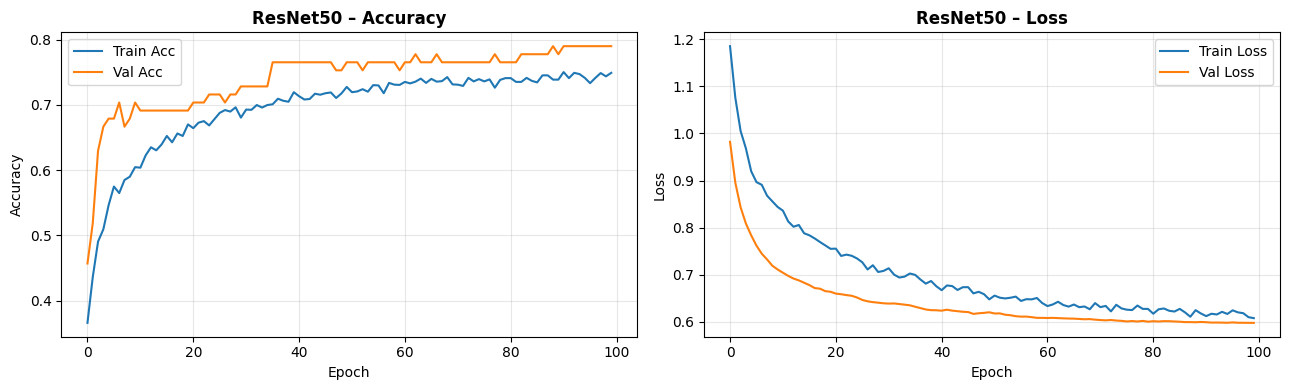


📊 Hasil ResNet-50 pada Test Set:
  Accuracy : 0.7037
  Precision: 0.7073
  Recall   : 0.7037
  F1-Score : 0.7048

              precision    recall  f1-score   support

       Sehat       0.80      0.74      0.77        27
      Blight       0.66      0.70      0.68        27
       Blast       0.67      0.67      0.67        27

    accuracy                           0.70        81
   macro avg       0.71      0.70      0.70        81
weighted avg       0.71      0.70      0.70        81



In [ ]:
print("=" * 60)
print("MODEL 4: ResNet-50 – Transfer Learning (DENGAN Augmentasi 4×)")
print("=" * 60)

# 1. Augmentasi
print("\nMembuat data augmented untuk training ResNet-50...")
X_train_aug, y_train_aug = augment_dataset(X_train, y_train, factor=AUG_FACTOR)
print(f"Training set setelah augmentasi: {len(X_train_aug)} gambar")

# 2. Preprocessing ImageNet
X_train_rn = normalize_imagenet(X_train_aug).astype(np.float32)
X_val_rn   = normalize_imagenet(X_val).astype(np.float32)
X_test_rn  = normalize_imagenet(X_test).astype(np.float32)

y_train_rn = to_categorical(y_train_aug, N_CLASSES)
y_val_rn   = to_categorical(y_val, N_CLASSES)

# 3. Bangun model
K.clear_session()

base_rn = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)
base_rn.trainable = False  # Freeze semua layer konvolusi

inputs_rn = Input(shape=(*IMAGE_SIZE, 3))
x = base_rn(inputs_rn, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs_rn = Dense(N_CLASSES, activation='softmax', dtype='float32')(x)

model_rn = Model(inputs_rn, outputs_rn)
model_rn.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_rn.summary()

# 4. Training
print("\nMelatih ResNet-50...")
history_rn = model_rn.fit(
    X_train_rn, y_train_rn,
    validation_data=(X_val_rn, y_val_rn),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('ResNet50'),
    verbose=1
)

# 5. Evaluasi
plot_training_history(history_rn, 'ResNet50')

y_pred_rn = np.argmax(model_rn.predict(X_test_rn, batch_size=BATCH_SIZE, verbose=0), axis=1)
rn_result = compute_metrics(y_test, y_pred_rn, CLASSES)
ALL_RESULTS['ResNet50'] = rn_result

print(f"\n📊 Hasil ResNet-50 pada Test Set:")
print(f"  Accuracy : {rn_result['accuracy']:.4f}")
print(f"  Precision: {rn_result['precision']:.4f}")
print(f"  Recall   : {rn_result['recall']:.4f}")
print(f"  F1-Score : {rn_result['f1']:.4f}")
print(f"\n{rn_result['report']}")

del X_train_aug, y_train_aug, X_train_rn, X_val_rn, X_test_rn, y_train_rn, y_val_rn
gc.collect()
K.clear_session()

## Model 5: CNN + SVM (Stacking / Hibrida)
> **Dengan augmentasi 4×.** CNN sebagai feature extractor, SVM sebagai classifier akhir.

MODEL 5: CNN + SVM Stacking (DENGAN Augmentasi 4×)


Model: "CNN_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,899 (1.74 MB)

 Trainable params: 455,939 (1.74 MB)

...

162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8264 - loss: 0.4315 - val_accuracy: 0.7531 - val_loss: 0.6209 - learning_rate: 5.0000e-05
Epoch 18/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8322 - loss: 0.4299 - val_accuracy: 0.7284 - val_loss: 0.5352 - learning_rate: 5.0000e-05
Epoch 19/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.8248 - loss: 0.4216 - val_accuracy: 0.7407 - val_loss: 0.6325 - learning_rate: 5.0000e-05
Epoch 20/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8329 - loss: 0.4121 - val_accuracy: 0.7284 - val_loss: 0.5394 - learning_rate: 5.0000e-05
Epoch 21/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8474 - loss: 0.4007

162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.8426 - loss: 0.4080 - val_accuracy: 0.7654 - val_loss: 0.6021 - learning_rate: 5.0000e-05
Epoch 22/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8441 - loss: 0.3978 - val_accuracy: 0.7160 - val_loss: 0.5270 - learning_rate: 5.0000e-05
Epoch 23/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8410 - loss: 0.4028 - val_accuracy: 0.7407 - val_loss: 0.5298 - learning_rate: 5.0000e-05
Epoch 24/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8499 - loss: 0.3915 - val_accuracy: 0.7654 - val_loss: 0.4954 - learning_rate: 5.0000e-05
Epoch 25/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8453 - loss: 0.3844 - val_accuracy: 0.7160 - val_loss: 0.5276 - learning_rate: 5.0000e-05
Epoch 26/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8584 - loss: 0.3718 - val_accuracy: 0.7531 - val_loss: 0.4799 - learning_rate: 5.0000e-05
Epoch 27/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/st

162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8708 - loss: 0.3331 - val_accuracy: 0.7901 - val_loss: 0.4873 - learning_rate: 2.5000e-05
Epoch 33/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8665 - loss: 0.3322 - val_accuracy: 0.7284 - val_loss: 0.4944 - learning_rate: 2.5000e-05
Epoch 34/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8882 - loss: 0.3200

162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8789 - loss: 0.3294 - val_accuracy: 0.8025 - val_loss: 0.4488 - learning_rate: 2.5000e-05
Epoch 35/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.8816 - loss: 0.3209 - val_accuracy: 0.7778 - val_loss: 0.4639 - learning_rate: 2.5000e-05
Epoch 36/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8669 - loss: 0.3331 - val_accuracy: 0.7901 - val_loss: 0.4554 - learning_rate: 2.5000e-05
Epoch 37/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8781 - loss: 0.3169 - val_accuracy: 0.7778 - val_loss: 0.4628 - learning_rate: 2.5000e-05
Epoch 38/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8684 - loss: 0.3233 - val_accuracy: 0.7654 - val_loss: 0.4725 - learning_rate: 2.5000e-05
Epoch 39/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8810 - loss: 0.3161
Epoch 39: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8777 - loss: 0.3230 - val_accuracy: 0.8148 - val_loss: 0.4960 - learning_rate: 2.5000e-05
Epoch 40/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8792 - loss: 0.3049 - val_accuracy: 0.7778 - val_loss: 0.4650 - learning_rate: 1.2500e-05
Epoch 41/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8781 - loss: 0.3058 - val_accuracy: 0.7778 - val_loss: 0.4538 - learning_rate: 1.2500e-05
Epoch 42/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8823 - loss: 0.3011 - val_accuracy: 0.8025 - val_loss: 0.4607 - learning_rate: 1.2500e-05
Epoch 43/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8831 - loss: 0.3011 - val_accuracy: 0.7901 - val_loss: 0.4545 - learning_rate: 1.2500e-05
Epoch 44/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8898 - loss: 0.2931
Epoch 44: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - acc

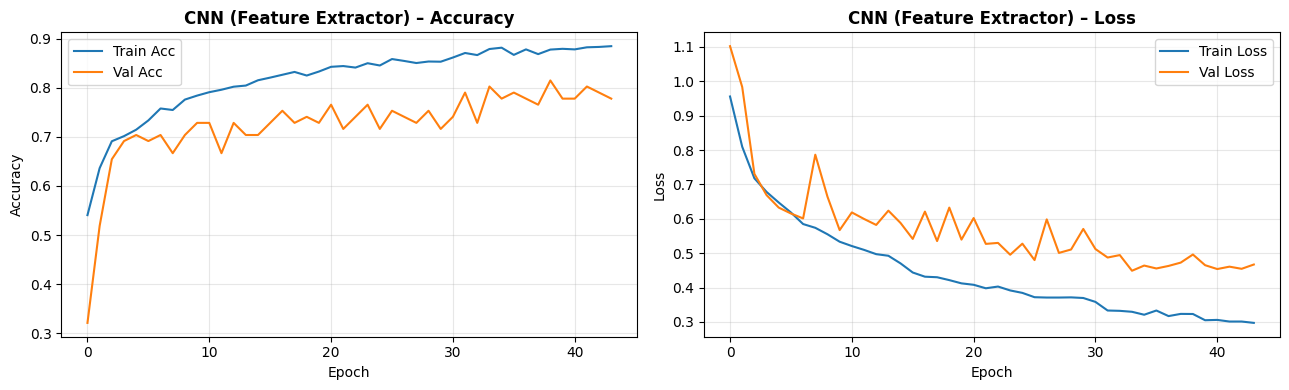

In [ ]:
print("=" * 60)
print("MODEL 5: CNN + SVM Stacking (DENGAN Augmentasi 4×)")
print("=" * 60)

# -------------------------------------------------------
#  TAHAP 1 — Bangun & Latih CNN Feature Extractor
# -------------------------------------------------------
K.clear_session()

def build_cnn_extractor(input_shape, n_classes):
    """
    CNN ringan: Conv→BN→ReLU→Pool × 3 + GAP + Dense(256, relu) + Dense(n_classes).
    Aktivasi ReLU digunakan di semua hidden layer.
    """
    inputs = Input(shape=input_shape)

    # Blok 1
    x = Conv2D(32, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Blok 2
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Blok 3
    x = Conv2D(128, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Blok 4
    x = Conv2D(256, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    features = Dense(256, activation='relu', name='feature_layer')(x)  # ← fitur diekstrak dari sini
    outputs  = Dense(n_classes, activation='softmax', dtype='float32', name='output')(features)

    return Model(inputs, outputs, name='CNN_Extractor')


model_cnn = build_cnn_extractor((*IMAGE_SIZE, 3), N_CLASSES)
model_cnn.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_cnn.summary()

# Augmentasi
print("\nMembuat data augmented untuk CNN...")
X_train_aug, y_train_aug = augment_dataset(X_train, y_train, factor=AUG_FACTOR)
print(f"Training set setelah augmentasi: {len(X_train_aug)} gambar")

X_train_cnn = normalize_standard(X_train_aug).astype(np.float32)
X_val_cnn   = normalize_standard(X_val).astype(np.float32)
X_test_cnn  = normalize_standard(X_test).astype(np.float32)

y_train_cnn_cat = to_categorical(y_train_aug, N_CLASSES)
y_val_cnn_cat   = to_categorical(y_val, N_CLASSES)

print("\nMelatih CNN feature extractor...")
history_cnn = model_cnn.fit(
    X_train_cnn, y_train_cnn_cat,
    validation_data=(X_val_cnn, y_val_cnn_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('CNN_extractor'),
    verbose=1
)
plot_training_history(history_cnn, 'CNN (Feature Extractor)')

In [ ]:
# -------------------------------------------------------
#  TAHAP 2 — Ekstraksi Fitur 256-dim dari Layer 'feature_layer'
# -------------------------------------------------------
print("Mengekstraksi fitur 256-dim dari CNN...")

feature_extractor = Model(
    inputs=model_cnn.input,
    outputs=model_cnn.get_layer('feature_layer').output,
    name='Feature_Extractor'
)

# Gunakan data ASLI (bukan augmented) untuk ekstraksi fitur training
X_train_orig_norm = normalize_standard(X_train).astype(np.float32)

feat_train = feature_extractor.predict(X_train_orig_norm, batch_size=BATCH_SIZE, verbose=1)
feat_val   = feature_extractor.predict(X_val_cnn,         batch_size=BATCH_SIZE, verbose=0)
feat_test  = feature_extractor.predict(X_test_cnn,        batch_size=BATCH_SIZE, verbose=0)

print(f"Dimensi fitur CNN: {feat_train.shape}")

# -------------------------------------------------------
#  TAHAP 3 — Latih SVM pada fitur CNN
# -------------------------------------------------------
print("\nMelatih SVM pada fitur CNN...")
scaler_cnn_svm = StandardScaler()
feat_train_sc = scaler_cnn_svm.fit_transform(feat_train)
feat_test_sc  = scaler_cnn_svm.transform(feat_test)

param_grid_cnnsvm = {
    'C'    : [1, 10, 100],
    'gamma': ['scale', 'auto']
}
svm_on_cnn = GridSearchCV(
    SVC(kernel='rbf', decision_function_shape='ovr', random_state=SEED),
    param_grid_cnnsvm, cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)
svm_on_cnn.fit(feat_train_sc, y_train)
print(f"Best params CNN+SVM: {svm_on_cnn.best_params_}  |  CV: {svm_on_cnn.best_score_:.4f}")

# Evaluasi
cnnsvm_result = evaluate_model_sk(svm_on_cnn, feat_test_sc, y_test, CLASSES)
ALL_RESULTS['CNN+SVM'] = cnnsvm_result

print(f"\n📊 Hasil CNN+SVM pada Test Set:")
print(f"  Accuracy : {cnnsvm_result['accuracy']:.4f}")
print(f"  Precision: {cnnsvm_result['precision']:.4f}")
print(f"  Recall   : {cnnsvm_result['recall']:.4f}")
print(f"  F1-Score : {cnnsvm_result['f1']:.4f}")
print(f"\n{cnnsvm_result['report']}")

del X_train_aug, y_train_aug, X_train_cnn, X_val_cnn, X_test_cnn
del feat_train, feat_val, feat_test, feat_train_sc, feat_test_sc
gc.collect()
K.clear_session()

Mengekstraksi fitur 256-dim dari CNN...


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Dimensi fitur CNN: (648, 256)

Melatih SVM pada fitur CNN...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params CNN+SVM: {'C': 100, 'gamma': 'scale'}  |  CV: 0.9089

📊 Hasil CNN+SVM pada Test Set:
  Accuracy : 0.9136
  Precision: 0.9230
  Recall   : 0.9136
  F1-Score : 0.9142

              precision    recall  f1-score   support

       Sehat       1.00      0.96      0.98        27
      Blight       0.96      0.81      0.88        27
       Blast       0.81      0.96      0.88        27

    accuracy                           0.91        81
   macro avg       0.92      0.91      0.91        81
weighted avg       0.92      0.91      0.91        81



## 6. Perbandingan & Visualisasi Semua Model

In [ ]:
# ===================================================
#  TABEL REKAPITULASI METRIK
# ===================================================

model_names = list(ALL_RESULTS.keys())
metrics_keys = ['accuracy', 'precision', 'recall', 'f1']
labels_id = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

df_results = pd.DataFrame({
    'Model': model_names,
    'Accuracy' : [ALL_RESULTS[m]['accuracy']  for m in model_names],
    'Precision': [ALL_RESULTS[m]['precision'] for m in model_names],
    'Recall'   : [ALL_RESULTS[m]['recall']    for m in model_names],
    'F1-Score' : [ALL_RESULTS[m]['f1']        for m in model_names],
    'Augmentasi': ['Tidak', 'Tidak', 'Ya (4×)', 'Ya (4×)', 'Ya (4×)']
})
df_results = df_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_results.index += 1

print("\n" + "=" * 70)
print("REKAPITULASI PERFORMA SEMUA MODEL")
print("=" * 70)
print(df_results.to_string(index=True))
df_results.to_csv(os.path.join(OUTPUT_DIR, "hasil_semua_model.csv"), index=True)
print(f"\nFile CSV disimpan: {OUTPUT_DIR}/hasil_semua_model.csv")


REKAPITULASI PERFORMA SEMUA MODEL
         Model  Accuracy  Precision    Recall  F1-Score Augmentasi
1      CNN+SVM  0.913580   0.923007  0.913580  0.914163    Ya (4×)
2  MobileNetV2  0.827160   0.827039  0.827160  0.825724    Ya (4×)
3          SVM  0.740741   0.753867  0.740741  0.743703      Tidak
4      SVM+HOG  0.740741   0.755280  0.740741  0.740645      Tidak
5     ResNet50  0.703704   0.707280  0.703704  0.704823    Ya (4×)

File CSV disimpan: ./output/hasil_semua_model.csv


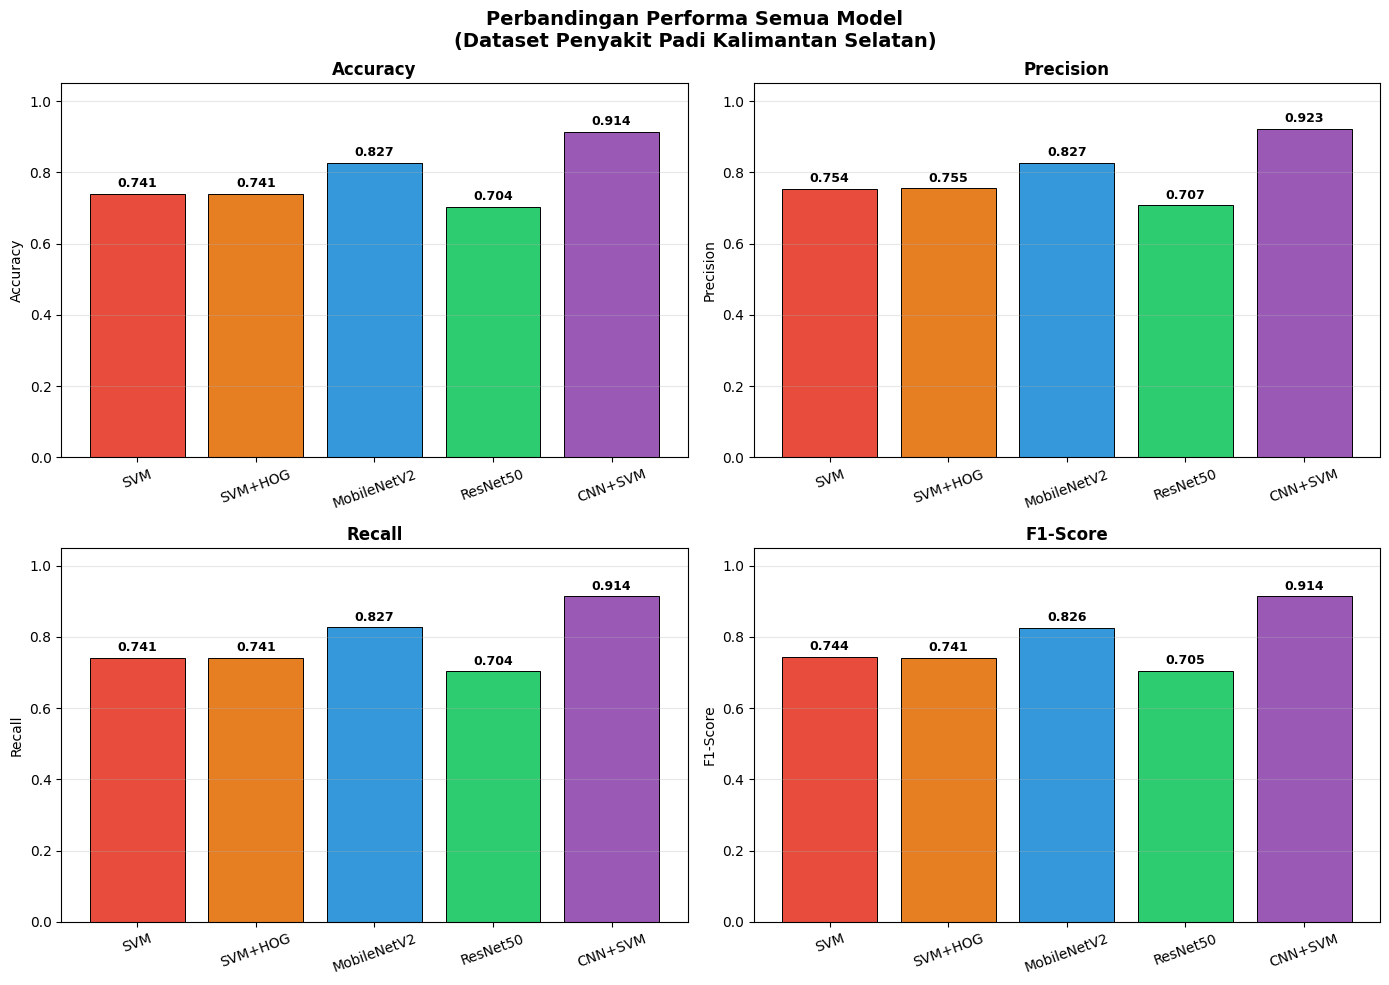

In [ ]:
# ===================================================
#  BAR CHART PERBANDINGAN SEMUA METRIK
# ===================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Perbandingan Performa Semua Model\n(Dataset Penyakit Padi Kalimantan Selatan)",
             fontsize=14, fontweight='bold')

colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71', '#9b59b6']

for ax, (metric_key, metric_label) in zip(axes.flat,
    [('accuracy','Accuracy'), ('precision','Precision'),
     ('recall','Recall'), ('f1','F1-Score')]):
    vals  = [ALL_RESULTS[m][metric_key] for m in model_names]
    bars  = ax.bar(model_names, vals, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(metric_label, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric_label)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_bar_chart_semua_model.png"), dpi=150, bbox_inches='tight')
plt.show()

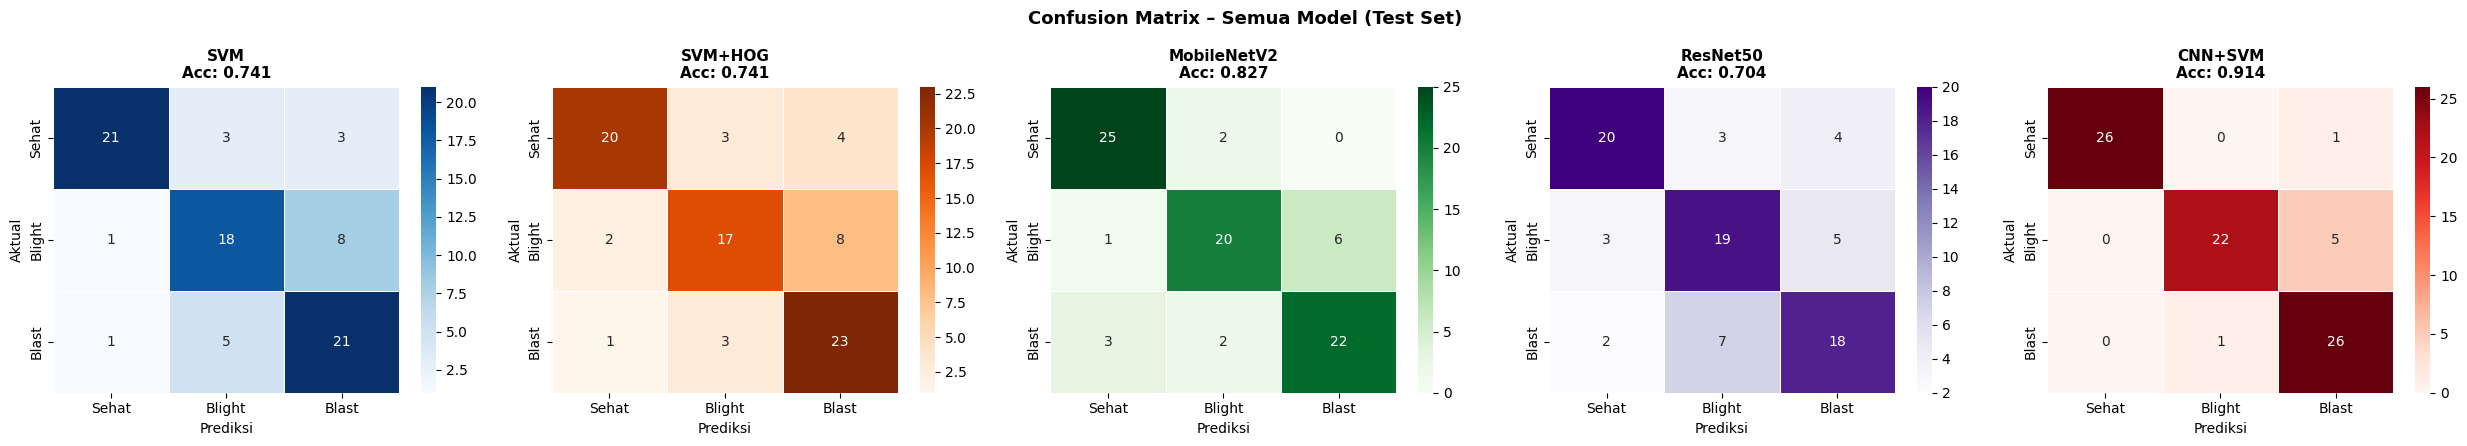

In [ ]:
# ===================================================
#  CONFUSION MATRIX SEMUA MODEL
# ===================================================

n_models = len(ALL_RESULTS)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
fig.suptitle("Confusion Matrix – Semua Model (Test Set)", fontsize=13, fontweight='bold')

cmaps = ['Blues', 'Oranges', 'Greens', 'Purples', 'Reds']
for ax, (model_name, result), cmap in zip(axes, ALL_RESULTS.items(), cmaps):
    plot_confusion_matrix(
        result['cm'], CLASSES,
        title=f"{model_name}\nAcc: {result['accuracy']:.3f}",
        ax=ax, cmap=cmap
    )

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_confusion_matrix_semua_model.png"), dpi=150, bbox_inches='tight')
plt.show()

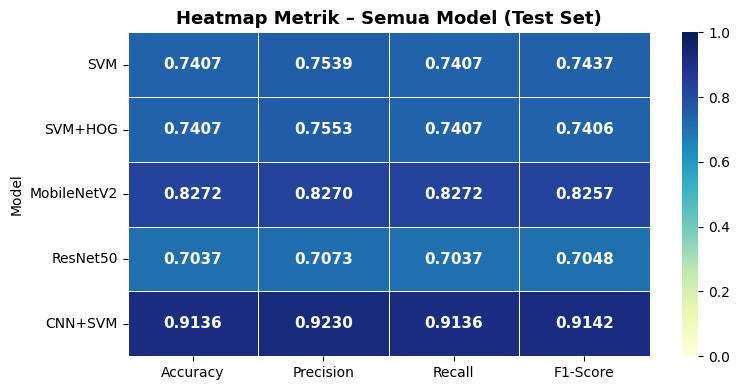

In [ ]:
# ===================================================
#  HEATMAP METRIK SEMUA MODEL
# ===================================================

heatmap_data = pd.DataFrame(
    {
        'Accuracy' : [ALL_RESULTS[m]['accuracy']  for m in model_names],
        'Precision': [ALL_RESULTS[m]['precision'] for m in model_names],
        'Recall'   : [ALL_RESULTS[m]['recall']    for m in model_names],
        'F1-Score' : [ALL_RESULTS[m]['f1']        for m in model_names],
    },
    index=model_names
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 11, 'weight': 'bold'}
)
ax.set_title("Heatmap Metrik – Semua Model (Test Set)", fontsize=13, fontweight='bold')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_heatmap_metrik.png"), dpi=150, bbox_inches='tight')
plt.show()

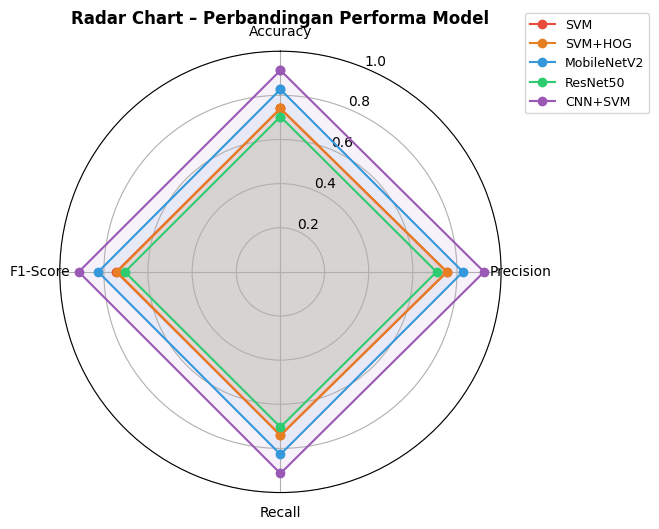

In [ ]:
# ===================================================
#  RADAR CHART PERBANDINGAN MODEL
# ===================================================

from matplotlib.patches import FancyArrowPatch

metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
n_metrics = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # Tutup loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics_radar)

for idx, model_name in enumerate(model_names):
    vals = [
        ALL_RESULTS[model_name]['accuracy'],
        ALL_RESULTS[model_name]['precision'],
        ALL_RESULTS[model_name]['recall'],
        ALL_RESULTS[model_name]['f1'],
    ]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=1.5, label=model_name, color=colors[idx])
    ax.fill(angles, vals, alpha=0.08, color=colors[idx])

ax.set_ylim(0, 1)
ax.set_title("Radar Chart – Perbandingan Performa Model", fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_radar_chart.png"), dpi=150, bbox_inches='tight')
plt.show()

## 7. Kesimpulan

In [ ]:
# ===================================================
#  KESIMPULAN OTOMATIS
# ===================================================

best_model = max(ALL_RESULTS, key=lambda m: ALL_RESULTS[m]['accuracy'])
worst_model = min(ALL_RESULTS, key=lambda m: ALL_RESULTS[m]['accuracy'])

print("\n" + "=" * 70)
print("KESIMPULAN")
print("=" * 70)
print(f"\n🏆 Model Terbaik : {best_model}")
print(f"   Accuracy       : {ALL_RESULTS[best_model]['accuracy']:.4f}")
print(f"   Precision      : {ALL_RESULTS[best_model]['precision']:.4f}")
print(f"   Recall         : {ALL_RESULTS[best_model]['recall']:.4f}")
print(f"   F1-Score       : {ALL_RESULTS[best_model]['f1']:.4f}")

print(f"\n📉 Model Terendah: {worst_model}")
print(f"   Accuracy       : {ALL_RESULTS[worst_model]['accuracy']:.4f}")

print("\n📋 Perbandingan Ringkas:")
print("-" * 50)
print(f"{'Model':<15} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-" * 50)
for name in sorted(ALL_RESULTS, key=lambda m: ALL_RESULTS[m]['accuracy'], reverse=True):
    r = ALL_RESULTS[name]
    marker = " ← TERBAIK" if name == best_model else ""
    print(f"{name:<15} {r['accuracy']:>8.4f} {r['precision']:>8.4f} {r['recall']:>8.4f} {r['f1']:>8.4f}{marker}")
print("-" * 50)

print("""
📌 Catatan:
  • SVM dan SVM+HOG: TANPA augmentasi data
  • MobileNetV2, ResNet-50, CNN+SVM: DENGAN augmentasi 4×
  • Dataset: 810 gambar primer lokal Kalimantan Selatan
  • Split: 80:10:10 (stratified, seed=42)
  • Ukuran input: 224×224 piksel
  • DL: Transfer learning ImageNet, frozen backbone
  • RAM optimal: ~12.7 GB sistem | 16 GB VRAM GPU
""")


KESIMPULAN

🏆 Model Terbaik : CNN+SVM
   Accuracy       : 0.9136
   Precision      : 0.9230
   Recall         : 0.9136
   F1-Score       : 0.9142

📉 Model Terendah: ResNet50
   Accuracy       : 0.7037

📋 Perbandingan Ringkas:
--------------------------------------------------
Model                Acc     Prec      Rec       F1
--------------------------------------------------
CNN+SVM           0.9136   0.9230   0.9136   0.9142 ← TERBAIK
MobileNetV2       0.8272   0.8270   0.8272   0.8257
SVM               0.7407   0.7539   0.7407   0.7437
SVM+HOG           0.7407   0.7553   0.7407   0.7406
ResNet50          0.7037   0.7073   0.7037   0.7048
--------------------------------------------------

📌 Catatan:
  • SVM dan SVM+HOG: TANPA augmentasi data
  • MobileNetV2, ResNet-50, CNN+SVM: DENGAN augmentasi 4×
  • Dataset: 810 gambar primer lokal Kalimantan Selatan
  • Split: 80:10:10 (stratified, seed=42)
  • Ukuran input: 224×224 piksel
  • DL: Transfer learning ImageNet, frozen backbone
  